In [29]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import pickle

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Optional: Text Cleaning
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

import warnings
warnings.filterwarnings("ignore")

In [30]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\H\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
# ==========================================
# Load Clean Dataset
# ==========================================

movies = pd.read_csv("../dataset/clean_movies.csv")

movies.head()

,Title,Tags,Genre,Overview,Original_Language,Popularity,Vote_Average,Vote_Count,Poster_Url,Year
0,Spider-Man: No Way Home,"action, adventure, science fiction peter parke...","action, adventure, science fiction",peter parker is unmasked and no longer able to...,en,5083.954,8.3,8940.0,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,The Batman,"crime, mystery, thriller in his second year of...","crime, mystery, thriller","in his second year of fighting crime, batman u...",en,3827.658,8.1,1151.0,https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
2,No Exit,thriller stranded at a rest stop in the mounta...,thriller,stranded at a rest stop in the mountains durin...,en,2618.087,6.3,122.0,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022
3,Encanto,"animation, comedy, family, fantasy the tale of...","animation, comedy, family, fantasy","the tale of an extraordinary family, the madri...",en,2402.201,7.7,5076.0,https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021
4,The King's Man,"action, adventure, thriller, war as a collecti...","action, adventure, thriller, war",as a collection of history's worst tyrants and...,en,1895.511,7.0,1793.0,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021


In [32]:
print(movies.shape)



(9826, 10)


In [33]:
movies.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9826 entries, 0 to 9825
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              9826 non-null   object 
 1   Tags               9826 non-null   object 
 2   Genre              9826 non-null   object 
 3   Overview           9826 non-null   object 
 4   Original_Language  9826 non-null   object 
 5   Popularity         9826 non-null   float64
 6   Vote_Average       9826 non-null   float64
 7   Vote_Count         9826 non-null   float64
 8   Poster_Url         9826 non-null   object 
 9   Year               9826 non-null   int64  
dtypes: float64(3), int64(1), object(6)
memory usage: 767.8+ KB


In [34]:

movies.head()

,Title,Tags,Genre,Overview,Original_Language,Popularity,Vote_Average,Vote_Count,Poster_Url,Year
0,Spider-Man: No Way Home,"action, adventure, science fiction peter parke...","action, adventure, science fiction",peter parker is unmasked and no longer able to...,en,5083.954,8.3,8940.0,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,The Batman,"crime, mystery, thriller in his second year of...","crime, mystery, thriller","in his second year of fighting crime, batman u...",en,3827.658,8.1,1151.0,https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
2,No Exit,thriller stranded at a rest stop in the mounta...,thriller,stranded at a rest stop in the mountains durin...,en,2618.087,6.3,122.0,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022
3,Encanto,"animation, comedy, family, fantasy the tale of...","animation, comedy, family, fantasy","the tale of an extraordinary family, the madri...",en,2402.201,7.7,5076.0,https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021
4,The King's Man,"action, adventure, thriller, war as a collecti...","action, adventure, thriller, war",as a collection of history's worst tyrants and...,en,1895.511,7.0,1793.0,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021


In [35]:
movies.isnull().sum()

Title                0
Tags                 0
Genre                0
Overview             0
Original_Language    0
Popularity           0
Vote_Average         0
Vote_Count           0
Poster_Url           0
Year                 0
dtype: int64

In [36]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

In [37]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z ]", "", text)

    # Split sentence into words
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Apply stemming
    words = [
        stemmer.stem(word)
        for word in words
    ]

    # Join words back into sentence
    return " ".join(words)

In [38]:
movies["Tags"] = movies["Tags"].apply(clean_text)

In [39]:
movies[["Title","Tags"]].head()

,Title,Tags
0,Spider-Man: No Way Home,action adventur scienc fiction peter parker un...
1,The Batman,crime mysteri thriller second year fight crime...
2,No Exit,thriller strand rest stop mountain blizzard re...
3,Encanto,anim comedi famili fantasi tale extraordinari ...
4,The King's Man,action adventur thriller war collect histori w...


In [40]:
# ==========================================
# Convert Text into Numerical Features
# ==========================================

tfidf = TfidfVectorizer(
    max_features=5000
)

In [41]:
vectors = tfidf.fit_transform(
    movies["Tags"]
)

In [42]:
vectors.shape

(9826, 5000)

In [43]:
vectors.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [44]:
# ==========================================
# Cosine Similarity
# ==========================================

similarity = cosine_similarity(vectors)

In [45]:
similarity.shape

(9826, 9826)

In [46]:
similarity

array([[1.        , 0.00297622, 0.0205408 , ..., 0.0332464 , 0.03574775,
        0.02783495],
       [0.00297622, 1.        , 0.01337037, ..., 0.08216669, 0.00277965,
        0.03470442],
       [0.0205408 , 0.01337037, 1.        , ..., 0.02421528, 0.02640581,
        0.00220116],
       ...,
       [0.0332464 , 0.08216669, 0.02421528, ..., 1.        , 0.00178315,
        0.00189651],
       [0.03574775, 0.00277965, 0.02640581, ..., 0.00178315, 1.        ,
        0.04406798],
       [0.02783495, 0.03470442, 0.00220116, ..., 0.00189651, 0.04406798,
        1.        ]])

In [47]:
# ==========================================
# Movie Recommendation Function
# ==========================================

def recommend(movie_name):

    # Check whether movie exists
    if movie_name not in movies["Title"].values:
        print("Movie not found.")
        return

    # Get movie index
    movie_index = movies[
        movies["Title"] == movie_name
    ].index[0]

    # Get similarity scores
    distances = similarity[movie_index]

    # Sort by similarity
    movie_list = sorted(
        list(enumerate(distances)),
        key=lambda x: x[1],
        reverse=True
    )[1:11]

    # Remove first movie (itself)
    recommendations = movie_list[1:11]

    print("="*50)
    print("Recommended Movies")
    print("="*50)

    for movie in recommendations:

        index = movie[0]

        print(

            movies.iloc[index].Title,

            "| Similarity:",

            round(movie[1],3)

        )

In [48]:
recommend("Spider-Man: No Way Home")

Recommended Movies
Spider-Man | Similarity: 0.3
Spider-Man: Homecoming | Similarity: 0.279
Spider-Man Strikes Back | Similarity: 0.243
Spider-Man: Far From Home | Similarity: 0.241
Shazam! Fury of the Gods | Similarity: 0.239
Spider-Man 2 | Similarity: 0.235
Peter's To-Do List | Similarity: 0.232
Spider-Man 3 | Similarity: 0.227
Italian Spiderman | Similarity: 0.224


In [49]:
def recommend(movie_name):

    if movie_name not in movies["Title"].values:
        print("Movie not found.")
        return

    movie_index = movies[
        movies["Title"] == movie_name
    ].index[0]

    distances = similarity[movie_index]

    movie_list = sorted(
    list(enumerate(distances)),
    key=lambda x: x[1],
    reverse=True
)[1:11]

    recommended = []

    for i in movie_list:

        movie = movies.iloc[i[0]]

        recommended.append({

            "Title":movie.Title,

            "Genre":movie.Genre,

            "Rating":movie.Vote_Average,

            "Popularity":movie.Popularity,

            "Year":movie.Year,

            "Poster":movie.Poster_Url,

            "Similarity":round(i[1],3)

        })

    return pd.DataFrame(recommended)

In [50]:
recommend("The Notebook")

,Title,Genre,Rating,Popularity,Year,Poster,Similarity
0,More the Merrier,"comedy, romance",6.8,128.130,2021,https://image.tmdb.org/t/p/original/uShw8wJ7K4...,0.237
1,The Switch,"comedy, romance, drama",6.2,16.141,2010,https://image.tmdb.org/t/p/original/g0Ll7tDEiO...,0.223
2,Two Brothers,"adventure, drama, family",7.1,15.083,2004,https://image.tmdb.org/t/p/original/5I2pRuJI3S...,0.217
3,Cirque du Soleil: Worlds Away,"fantasy, family, music, drama",7.0,13.899,2012,https://image.tmdb.org/t/p/original/jAt4ugebhX...,0.216
4,The Sound of Music,"drama, family, music, romance",7.7,25.391,1965,https://image.tmdb.org/t/p/original/xvXiJggaxR...,0.202
5,Above the Shadows,"fantasy, romance",6.9,16.202,2019,https://image.tmdb.org/t/p/original/3FrGhwhyZd...,0.199
6,Red Tails,"drama, action, adventure, history, war",6.5,58.233,2012,https://image.tmdb.org/t/p/original/jiORLnBsGc...,0.198
7,Like a Cat on a Highway,"family, comedy",6.5,16.105,2017,https://image.tmdb.org/t/p/original/7d3ljZjh3b...,0.195
8,The Other Man,"drama, thriller, mystery, romance",5.3,17.130,2008,https://image.tmdb.org/t/p/original/qtHxTrhdLj...,0.192
9,Unbroken,"drama, war",7.5,24.012,2014,https://image.tmdb.org/t/p/original/vAlHUjHwLW...,0.190


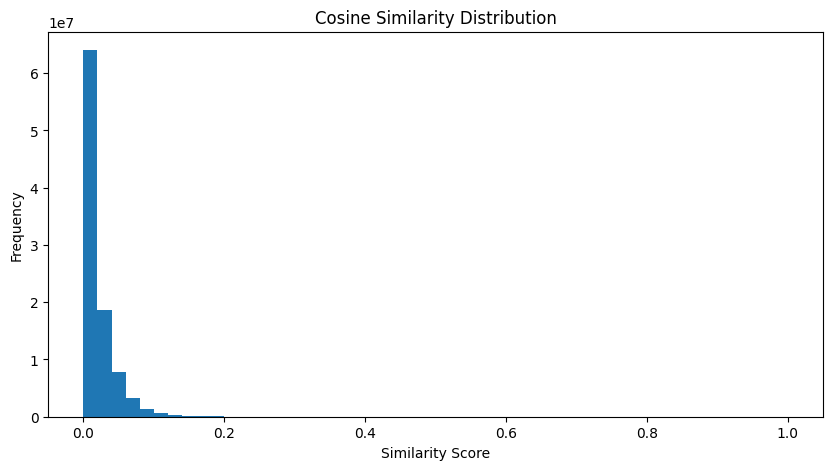

In [51]:
import matplotlib.pyplot as plt

scores = similarity.flatten()

plt.figure(figsize=(10,5))
plt.hist(scores, bins=50)
plt.title("Cosine Similarity Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

In [52]:
movie = "Spider-Man: No Way Home"

index = movies[movies["Title"] == movie].index[0]

scores = list(enumerate(similarity[index]))

scores = sorted(scores, key=lambda x: x[1], reverse=True)

for i in scores[:10]:
    print(movies.iloc[i[0]]["Title"], i[1])

Spider-Man: No Way Home 1.0000000000000002
Spider-Man 0.3331781798381897
Spider-Man 0.2997987437882545
Spider-Man: Homecoming 0.2785003176815895
Spider-Man Strikes Back 0.2427622006732113
Spider-Man: Far From Home 0.24139121691205764
Shazam! Fury of the Gods 0.23877520285697207
Spider-Man 2 0.23454091463197968
Peter's To-Do List 0.2317974742102672
Spider-Man 3 0.22695794699287006


In [53]:
import pickle

# Save similarity matrix
with open("../models/similarity.pkl", "wb") as f:
    pickle.dump(similarity, f)

# Save TF-IDF vectorizer
with open("../models/vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save movie dataframe
with open("../models/movies.pkl", "wb") as f:
    pickle.dump(movies, f)

print("All models saved successfully!")

All models saved successfully!


In [54]:
import pickle

movies = pickle.load(open("../models/movies.pkl", "rb"))

print(movies.columns.tolist())

['Title', 'Tags', 'Genre', 'Overview', 'Original_Language', 'Popularity', 'Vote_Average', 'Vote_Count', 'Poster_Url', 'Year']


In [55]:
print(movies["Poster_Url"].head())

0    https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1    https://image.tmdb.org/t/p/original/74xTEgt7R3...
2    https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3    https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4    https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
Name: Poster_Url, dtype: object


In [57]:
print(movies["Original_Language"].unique()[:10])

['en' 'ja' 'fr' 'hi' 'es' 'ru' 'de' 'th' 'ko' 'tr']
